# Sanity-check unfolding from `selected_xsec_overlay` rates

Copy of the `unfolding.ipynb` Wiener-SVD path, but **measurement counts** come from the
cached histogram pickle written by `selected_xsec_overlay.ipynb`
(`overlay_histdata.pkl`) instead of re-running `overlay_hists` on data DFs.

| Ingredient | Source |
|---|---|
| Measured = data − MC bkg | `overlay_histdata.pkl` (topology breakdown) |
| Response / efficiency / `nevts_allmc` | `signal_hists` on the **same MC** listed in the overlay `plot_set` |
| Fractional covariance | `category_syst_summary.npz` → `total_xsec` (same as `unfolding.ipynb`) |
| `xsec_unit` | Gen1 ray-trace flux × POT from overlay pot label (or hdr) |

Run after `selected_xsec_overlay.ipynb` has written counts for the active plot set.


In [1]:
%load_ext autoreload
%autoreload 2


In [12]:
import re
import sys
import pickle
from os import path, makedirs
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana")

from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.final_selected_evt_vars import CORE_SELECTED_EVT_VARIABLE_CONFIGS
from analysis_village.numucc_1p0pi.selected_xsec_overlay_hist import load_overlay_counts, histdata_pkl_path
from analysis_village.numucc_1p0pi.utils import (
    get_response_matrix,
    cov_from_fraccov,
    get_category_summary_syst_unc,
    get_integrated_flux,
    get_pot_str,
    signal_hists,
    plot_unfolded_result,
    plot_heatmap,
)
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.numucc_1p0pi.categories import get_topo_category
from pyanalib.variable_calculator import add_mc_cc1p0pi_tki_mcnu
from analysis_village.numucc_1p0pi.syst_disk_layout import category_summary_npz_path
from analysis_village.unfolding.wienersvd import WienerSVD

plt.style.use("presentation.mplstyle")


In [3]:
# --- point at the overlay plot set you want to sanity-check ---
OVERLAY_OUT_DIR = Path(
    "/exp/sbnd/data/users/munjung/sanity_check/selected_chi2fix_qual_cut"
)
OVERLAY_PKL = Path(histdata_pkl_path(str(OVERLAY_OUT_DIR)))

SYST_DISK_ROOT = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final"
CATEGORY_SUMMARY_NPZ = category_summary_npz_path(SYST_DISK_ROOT)
UNFOLDING_SYST_KIND = "xsec"  # total_xsec (GENIE xsec path)

OUT_DIR = OVERLAY_OUT_DIR / "unfold_sanity"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PKL = OUT_DIR / "unfolding_ingredients_and_results.pkl"
SAVE_FIG_DIR = OUT_DIR / "plots"
SAVE_FIG_DIR.mkdir(parents=True, exist_ok=True)

C_TYPE = 2
NORM_TYPE = 0.0
N_MAX_CONCAT = 999
KEYS2LOAD_MC = ["hdr", "evt", "mcnu"]

save_fig = True
approval = "internal"

print("overlay pkl :", OVERLAY_PKL)
print("syst disk   :", SYST_DISK_ROOT)
print("category npz:", CATEGORY_SUMMARY_NPZ)
print("output      :", OUT_PKL)


overlay pkl : /exp/sbnd/data/users/munjung/sanity_check/selected_chi2fix_qual_cut/overlay_histdata.pkl
syst disk   : /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final
category npz: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz
output      : /exp/sbnd/data/users/munjung/sanity_check/selected_chi2fix_qual_cut/unfold_sanity/unfolding_ingredients_and_results.pkl


## Load overlay event rates

Topology `mc_hist` rows follow `get_topo_category(..., ret_cuts=True)` fill order:
**cosmic → … → signal last**. Background is everything except the last MC layer,
plus intime / offbeam / dirt if present (same bookkeeping as `overlay_hists_from_histdata`).


In [4]:
payload = load_overlay_counts(str(OVERLAY_OUT_DIR))
assert payload is not None, f"missing {OVERLAY_PKL}"
assert payload.get("format") == "selected_xsec_overlay_histdata_v1"

plot_set = payload["plot_set"]
pot_label = payload["pot_label"]
histdata = payload["histdata"]
var_save_names = list(payload["var_save_names"])

print("format     :", payload["format"])
print("pot_label  :", pot_label)
print("plot_set   :", plot_set)
print("vars       :", var_save_names)
print("n histdata :", len(histdata))


def parse_pot_from_label(label: str) -> float:
    """Invert ``get_pot_str`` as used in overlay pot labels."""
    m = re.search(
        r"POT=([0-9.]+)\s*\$\\times\s*10\^\{([0-9+-]+)\}\$",
        label,
    )
    if not m:
        raise ValueError(f"could not parse POT from {label!r}")
    return float(m.group(1)) * 10 ** int(m.group(2))


def rates_from_overlay(hd, *, cosmic_estimate: str = "intime"):
    """Return data, MC-signal, MC-bkg arrays matching overlay stacking."""
    data = np.asarray(hd.data_hist, dtype=float)
    mc = np.asarray(hd.mc_hist, dtype=float)
    assert mc.ndim == 2 and mc.shape[0] >= 1
    signal = mc[-1].astype(float)
    total_mc = mc.sum(axis=0).astype(float)

    prefer_offbeam = str(cosmic_estimate).lower() == "offbeam"
    cosmic = None
    if prefer_offbeam:
        if getattr(hd, "has_offbeam", False) and hd.offbeam_hist is not None:
            cosmic = np.asarray(hd.offbeam_hist, dtype=float)
        elif getattr(hd, "has_intime", False) and hd.intime_hist is not None:
            cosmic = np.asarray(hd.intime_hist, dtype=float)
    else:
        if getattr(hd, "has_intime", False) and hd.intime_hist is not None:
            cosmic = np.asarray(hd.intime_hist, dtype=float)
        elif getattr(hd, "has_offbeam", False) and hd.offbeam_hist is not None:
            cosmic = np.asarray(hd.offbeam_hist, dtype=float)
    if cosmic is not None:
        total_mc = total_mc + cosmic

    if getattr(hd, "has_dirt", False) and hd.dirt_hist is not None:
        total_mc = total_mc + np.asarray(hd.dirt_hist, dtype=float)

    bkg = total_mc - signal
    return {
        "bins": np.asarray(hd.bins, dtype=float),
        "data": data,
        "signal_mc": signal,
        "bkg_mc": bkg,
        "data_minus_bkg": data - bkg,
        "total_mc": total_mc,
    }


# smoke-check one variable
_demo = rates_from_overlay(histdata[("tki-del_Tp", "topology")])
print("tki-del_Tp data sum        :", float(_demo["data"].sum()))
print("tki-del_Tp signal MC sum   :", float(_demo["signal_mc"].sum()))
print("tki-del_Tp bkg MC sum      :", float(_demo["bkg_mc"].sum()))
print("tki-del_Tp data-bkg sum    :", float(_demo["data_minus_bkg"].sum()))

DATA_TOT_POT = parse_pot_from_label(pot_label)
print(f"DATA_TOT_POT from label = {DATA_TOT_POT:.6e}")


format     : selected_xsec_overlay_histdata_v1
pot_label  : Events / Bin (POT=1.22$\times 10^{20}$)
plot_set   : {'tag': 'selected_chi2fix_qual_cut', 'output_dir': '/exp/sbnd/data/users/munjung/sanity_check/selected_chi2fix_qual_cut', 'mc_dir': '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real', 'mc_filename_str': 'sel_mup-mc-fvfix-chi2fix-real', 'data_dir': '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_001941__sel_mup-data-1e20-fvfix-chi2fix-real', 'data_filename_str': 'sel_mup-data-1e20-fvfix-chi2fix-real'}
vars       : ['muon-p', 'muon-dir_z', 'proton-p', 'proton-dir_z', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_p', 'tki-del_alpha', 'tki-del_phi']
n histdata : 20
tki-del_Tp data sum        : 17935.0
tki-del_Tp signal MC sum   : 15942.39361011982
tki-del_Tp bkg MC sum      : 1479.8751492500305
tki-del_Tp data-bkg sum    : 16455.12485074997
DATA_TOT_POT from label = 1.220000e+20


## Load production MC (response only)

Data event rates are taken from the overlay pickle. MC DFs are still needed for
`signal_hists` → response / efficiency / truth model. Paths come from the overlay
`plot_set` so they match the counts pickle.


In [ ]:
assert plot_set is not None, "overlay payload missing plot_set"
DIR_GENIE = plot_set["mc_dir"]
MC_FILENAME_STR = plot_set["mc_filename_str"]

mc_dfs = dfs_from_dir(
    DIR_GENIE,
    filename_str=MC_FILENAME_STR,
    keys2load=KEYS2LOAD_MC,
    n_max_concat=N_MAX_CONCAT,
)
mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]
mc_nu_df = mc_dfs["mcnu"]


Found 999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fi

100%|██████████| 999/999 [06:50<00:00,  2.43it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
MC dir: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_09_002202__sel_mup-mc-fvfix-chi2fix-real
MC: evt=15,513  mcnu=3,588,529  mc_tot_pot=1.081e+20  scale=1.129e+00
pot_label: Events / Bin (POT=1.22$\times 10^{20}$)


/tmp/ipykernel_1358926/3966441890.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))


In [13]:
def _prefix_mcnu_columns(mc_nu_df):
    """Leading ``mc`` level for category / signal helpers (mcnu HDF has flat truth cols)."""
    if mc_nu_df is None or len(mc_nu_df) == 0:
        return mc_nu_df
    if not isinstance(mc_nu_df.columns, pd.MultiIndex):
        return mc_nu_df
    first = mc_nu_df.columns.get_level_values(0)
    if np.all(first == "mc"):
        return mc_nu_df
    out = mc_nu_df.copy()
    out.columns = pd.MultiIndex.from_tuples(
        [tuple(["mc"] + list(c)) for c in mc_nu_df.columns]
    )
    return out


# mcnu truth is stored without an ``mc`` block; category helpers and signal_cut need ``df.mc.*``.
mc_nu_df = _prefix_mcnu_columns(mc_nu_df)
# TKI ``del_*`` attached at top level (matches VariableConfig.var_nu_col for tki-*).
mc_nu_df = add_mc_cc1p0pi_tki_mcnu(mc_nu_df)

# Topology category used by signal_hists (signal == 1); see categories.get_topo_category
if "topo_categ" not in mc_evt_df.columns:
    mc_evt_df.loc[:, "topo_categ"] = get_topo_category(mc_evt_df)
if "topo_categ" not in mc_nu_df.columns:
    mc_nu_df.loc[:, "topo_categ"] = get_topo_category(mc_nu_df)

print("topo_categ (evt):", mc_evt_df["topo_categ"].value_counts().to_dict())
print("topo_categ (mcnu):", mc_nu_df["topo_categ"].value_counts().to_dict())
print("mcnu has mc block:", "mc" in mc_nu_df.columns.get_level_values(0))
print("mcnu has del_Tp:", "del_Tp" in mc_nu_df.columns.get_level_values(0))


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


topo_categ (evt): {1: 14194, 3: 441, 2: 440, 4: 227, -1: 178, 0: 33}
topo_categ (mcnu): {0: 2950260, 3: 320290, 4: 182644, 1: 78484, 2: 56851}
mcnu has mc block: True
mcnu has del_Tp: True


## Exposure: `xsec_unit`


In [14]:
from analysis_village.flux.raytrace_volume_defs import (
    FV_SPLIT_TRUNCY_BOXES,
    RAYTRACE_VOLUME_LABEL,
)

FLUX_FILE = "/exp/sbnd/data/users/munjung/flux/SBND_gsimple_raytrace/Gen1.root"
FLUX_FV = "FV_split_truncY"
XSEC_TOT_POT = DATA_TOT_POT

print(f"Fiducial volume ({FLUX_FV}): {RAYTRACE_VOLUME_LABEL[FLUX_FV]}")
V_SBND = 0.0
for i, box in enumerate(FV_SPLIT_TRUNCY_BOXES):
    dx = box["x_range"][1] - box["x_range"][0]
    dy = box["y_range"][1] - box["y_range"][0]
    dz = box["z_range"][1] - box["z_range"][0]
    V_SBND += dx * dy * dz
print(f"V_SBND = {V_SBND:.6e} cm³")

integrated_flux_per_pot = get_integrated_flux(FLUX_FILE, plot=False)
integrated_flux = integrated_flux_per_pot * XSEC_TOT_POT
N_TARGETS = (RHO * V_SBND / M_AR) * N_A
xsec_unit = 1.0 / (integrated_flux * N_TARGETS)

print(f"Integrated flux × POT = {integrated_flux:.6e} ν/cm²")
print(f"N_targets = {N_TARGETS:.4e}")
print(f"xsec_unit = {xsec_unit:.6e} cm²/nucleon")


Fiducial volume (FV_split_truncY): $10<|x|<190$: $|y|<190$ ($10<z<250$), $-190<y<100$ ($250<z<450$)
V_SBND = 5.371200e+07 cm³
Integrated flux: 1.518e-08
Integrated flux × POT = 1.851974e+12 ν/cm²
N_targets = 1.1203e+30
xsec_unit = 4.820023e-43 cm²/nucleon


## Unfold all CORE variables present in the overlay pickle



=== muon-p ===
key ('/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/CategorySummary/category_syst_summary.npz', 'muon-p', 'xsec') in cache
muon-p            χ²/ndof = 11.0/12
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


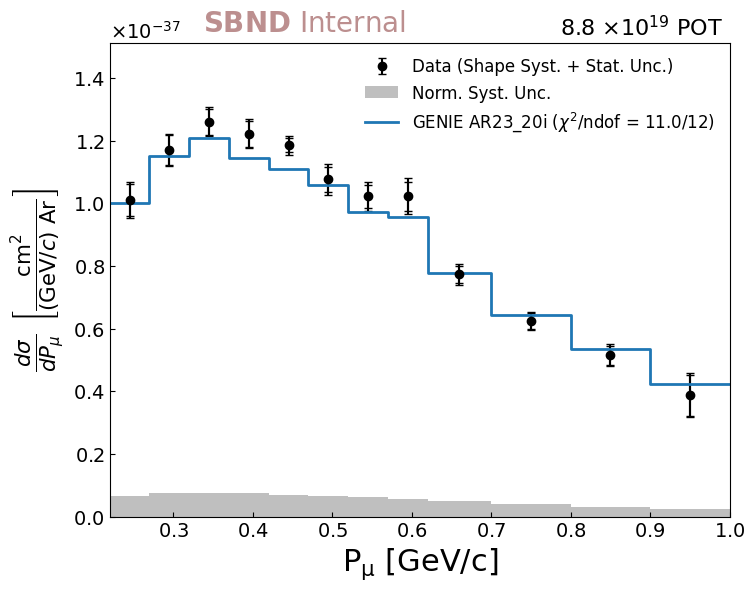

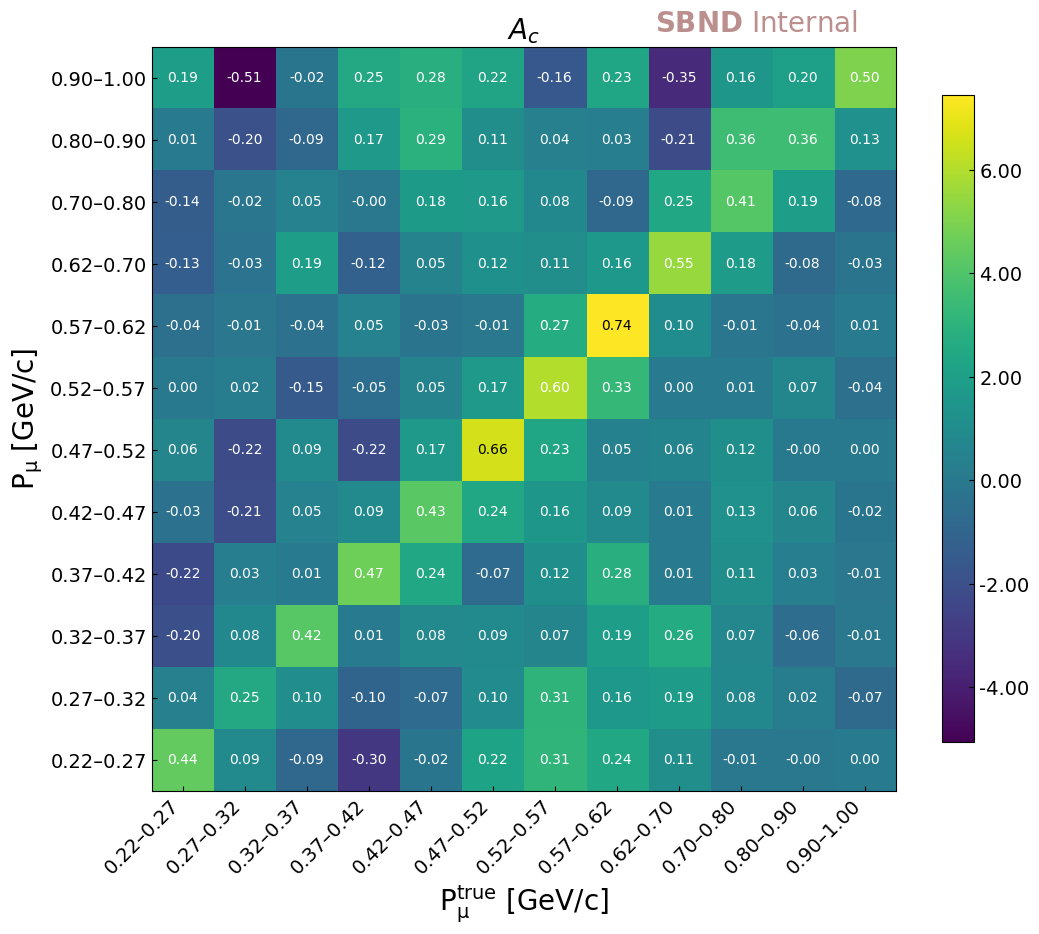


=== muon-dir_z ===
muon-dir_z        χ²/ndof = 98.2/14
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


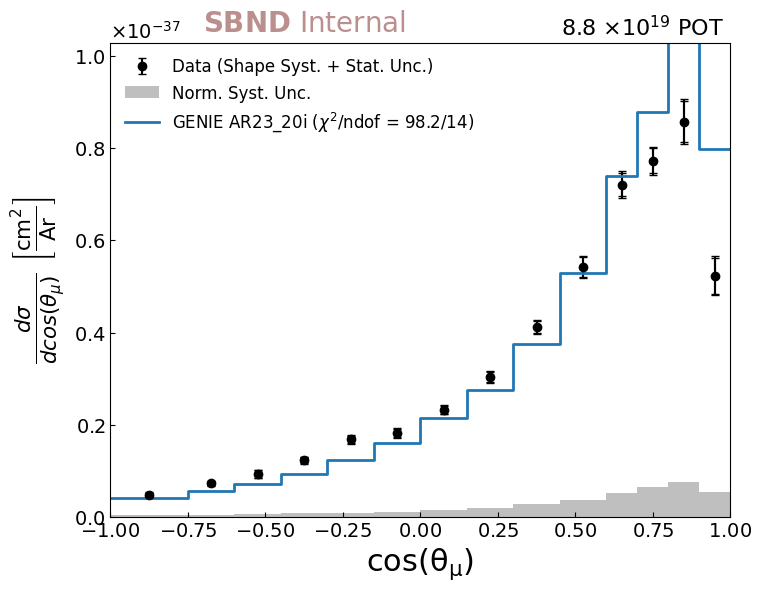

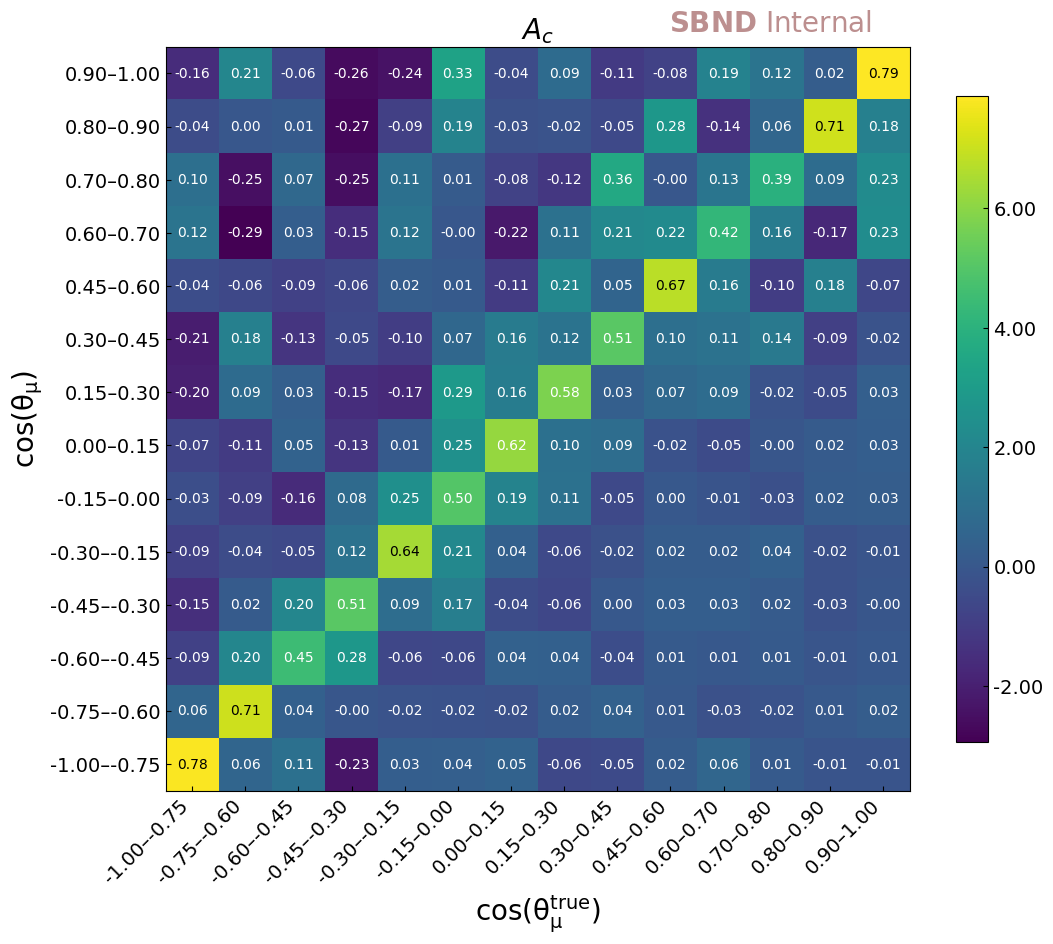


=== proton-p ===
proton-p          χ²/ndof = 47.1/13
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


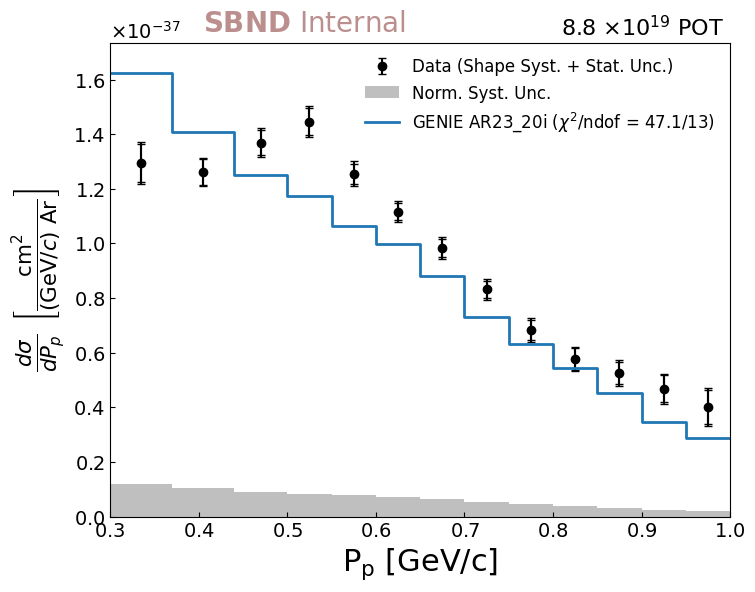

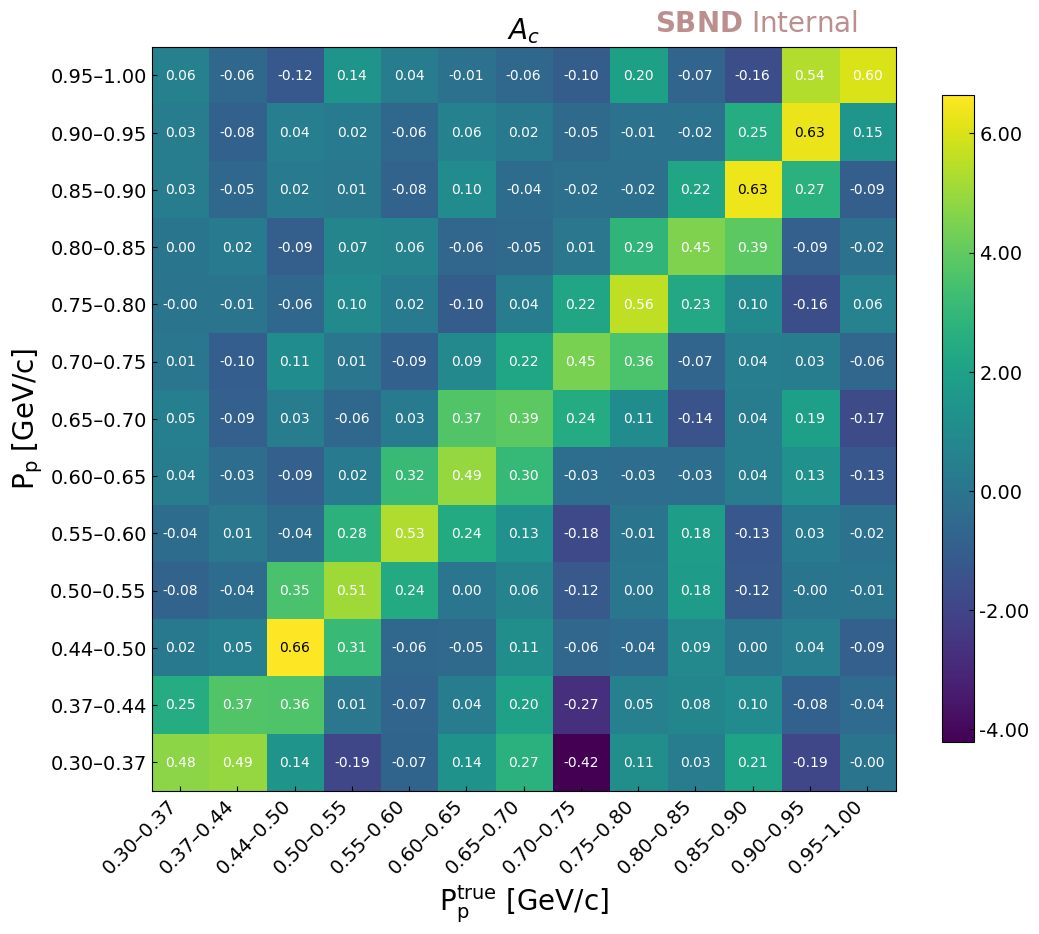


=== proton-dir_z ===
proton-dir_z      χ²/ndof = 21.9/10
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


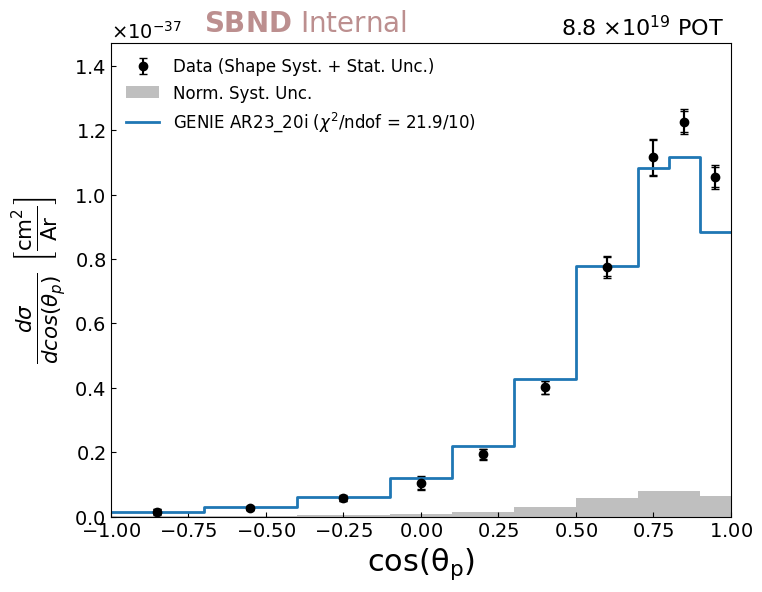

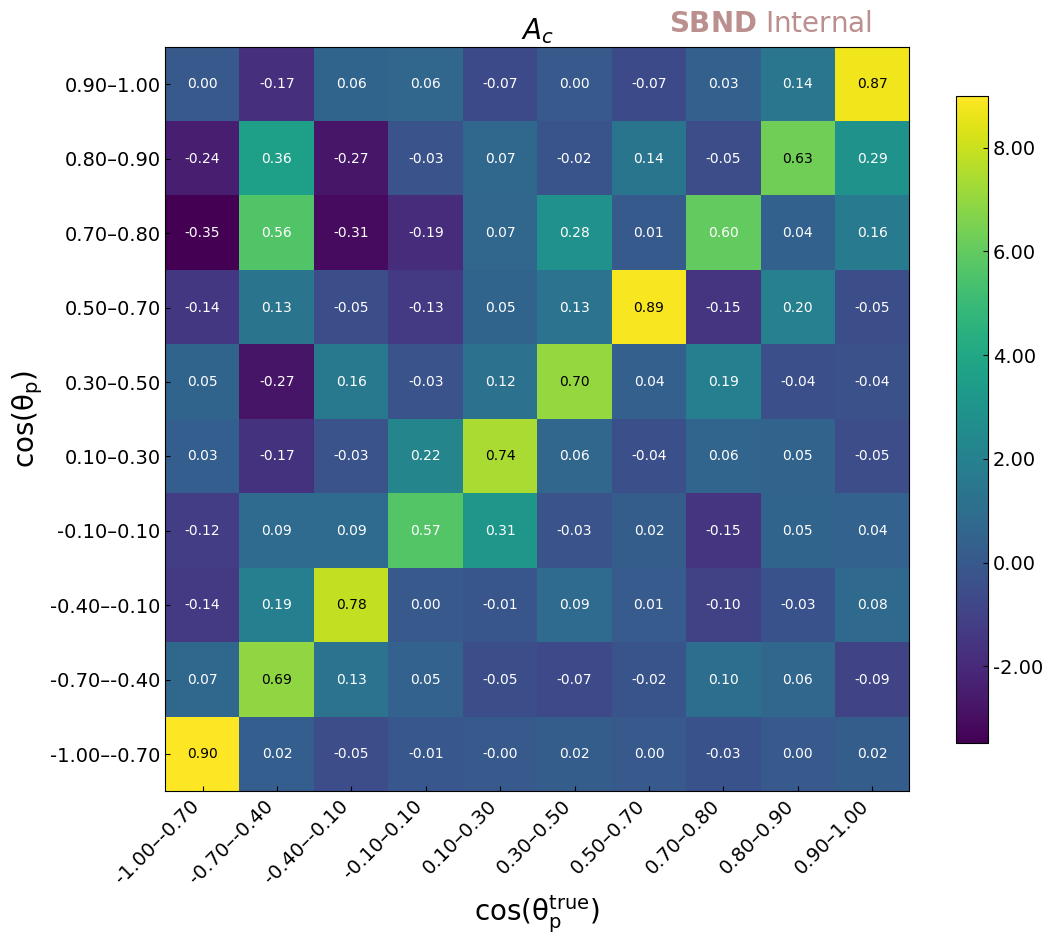


=== tki-del_Tp ===
tki-del_Tp        χ²/ndof = 36.8/12
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


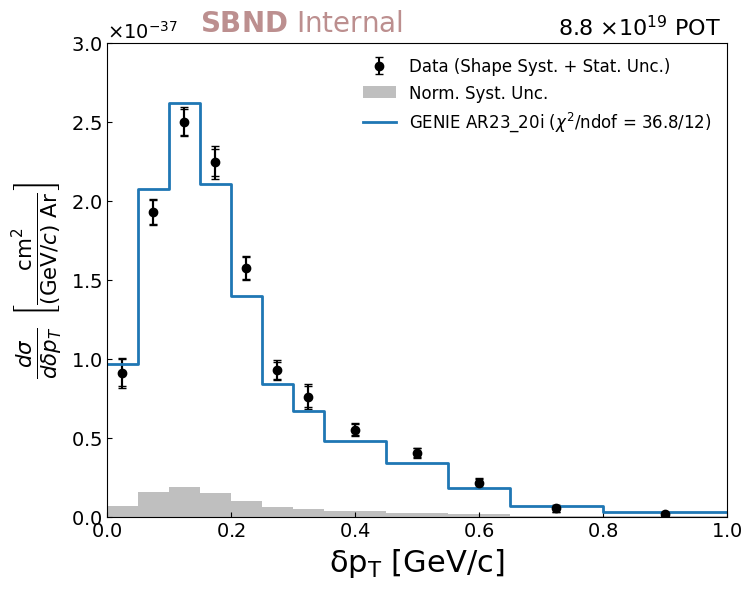

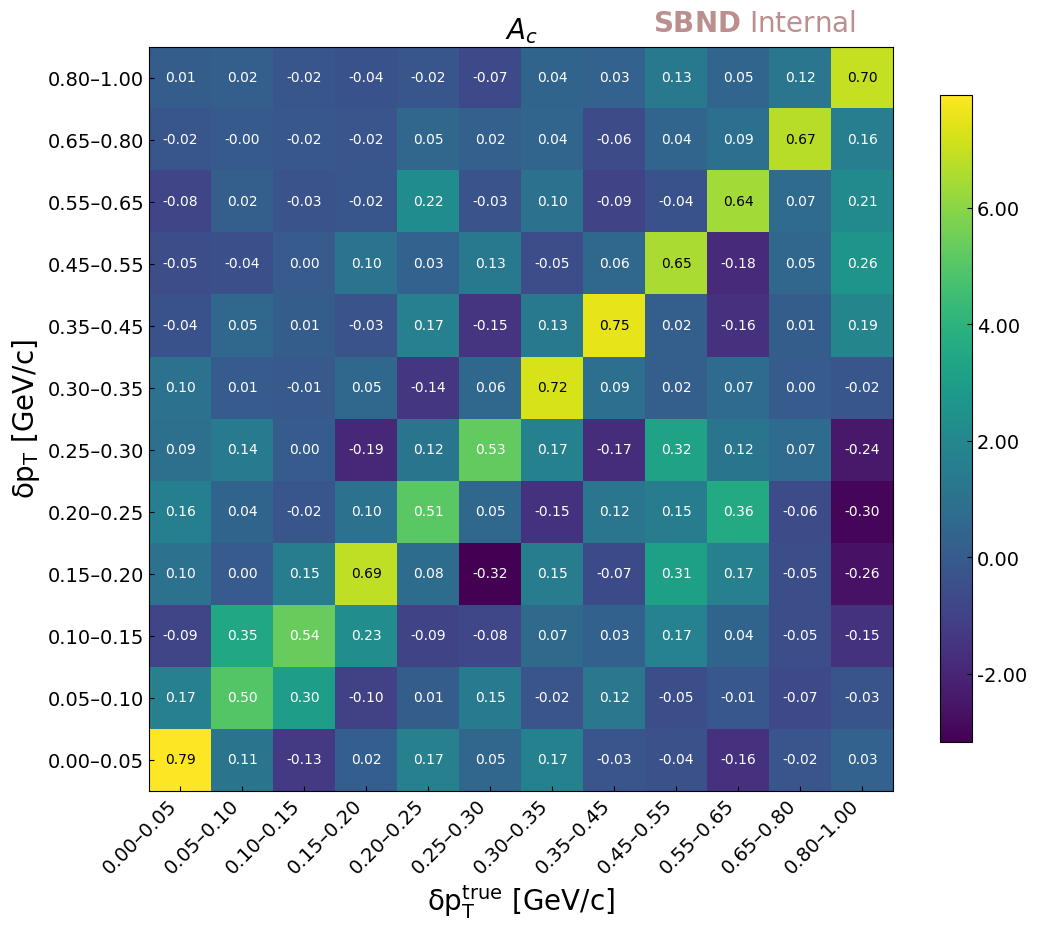


=== tki-del_Tp_x ===
tki-del_Tp_x      χ²/ndof = 16.0/13
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


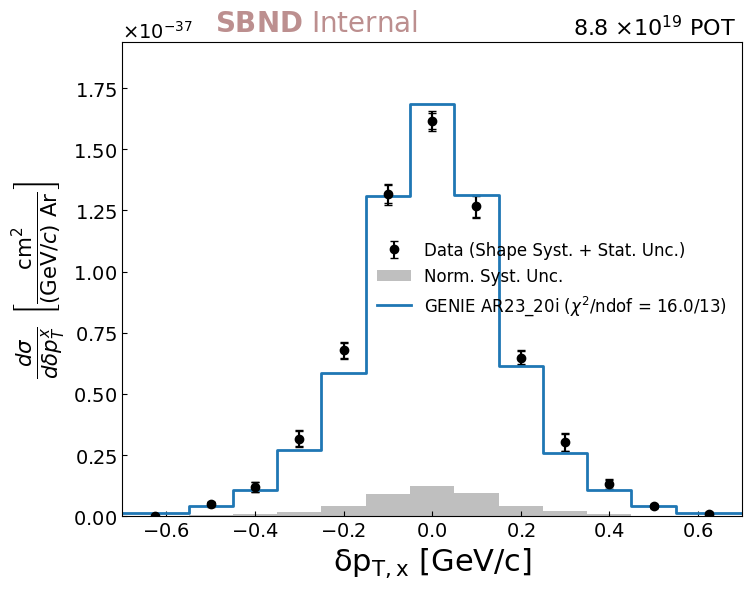

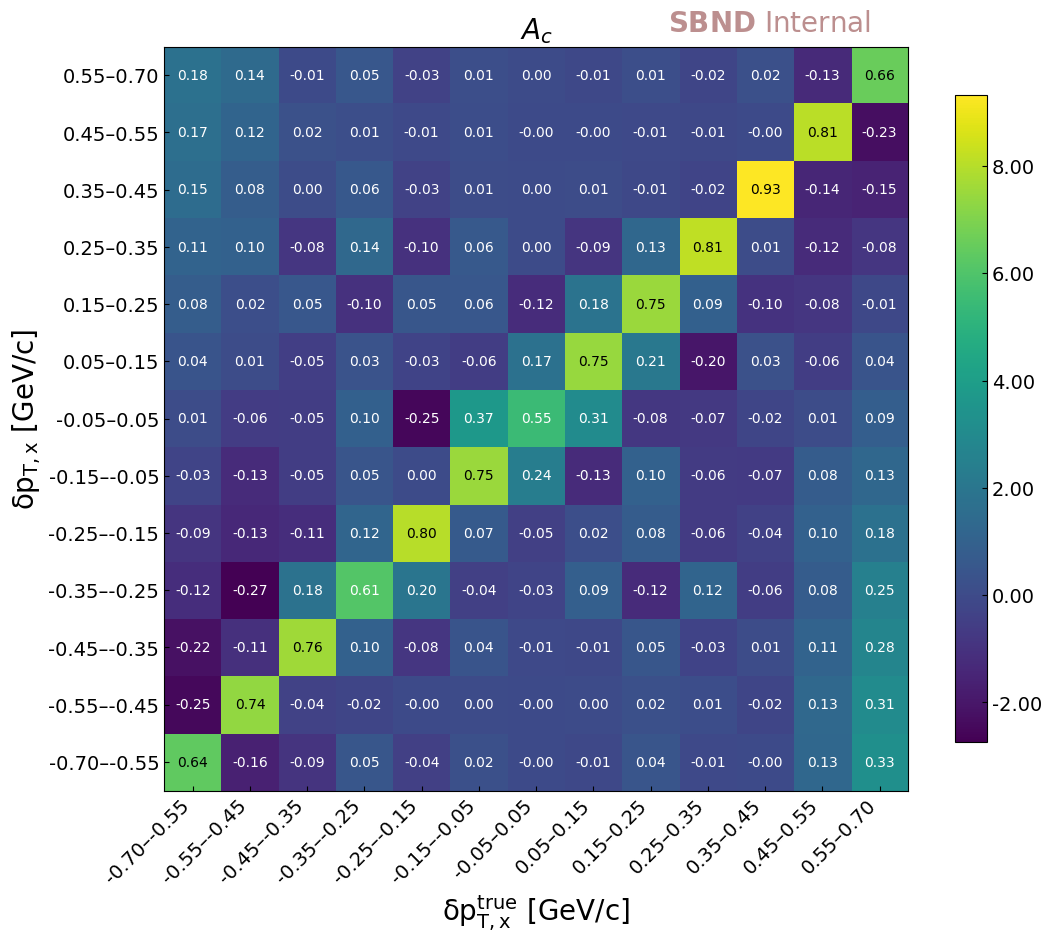


=== tki-del_Tp_y ===
tki-del_Tp_y      χ²/ndof = 46.6/13
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


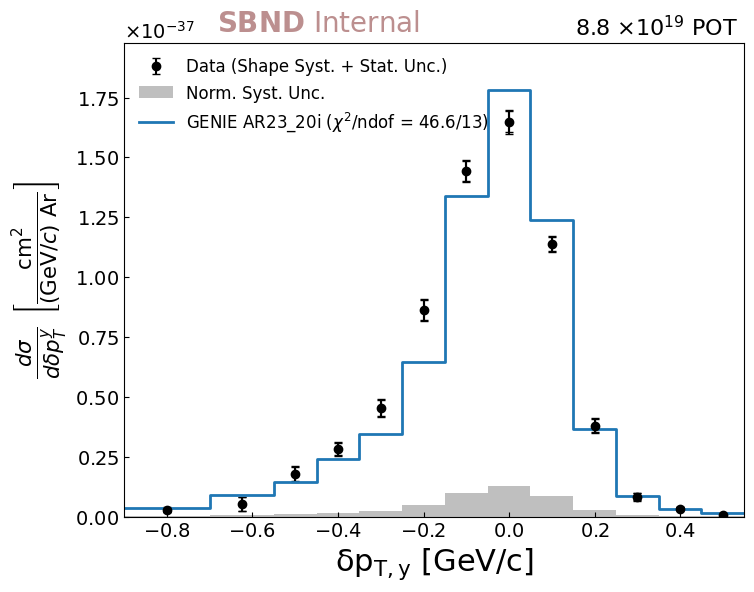

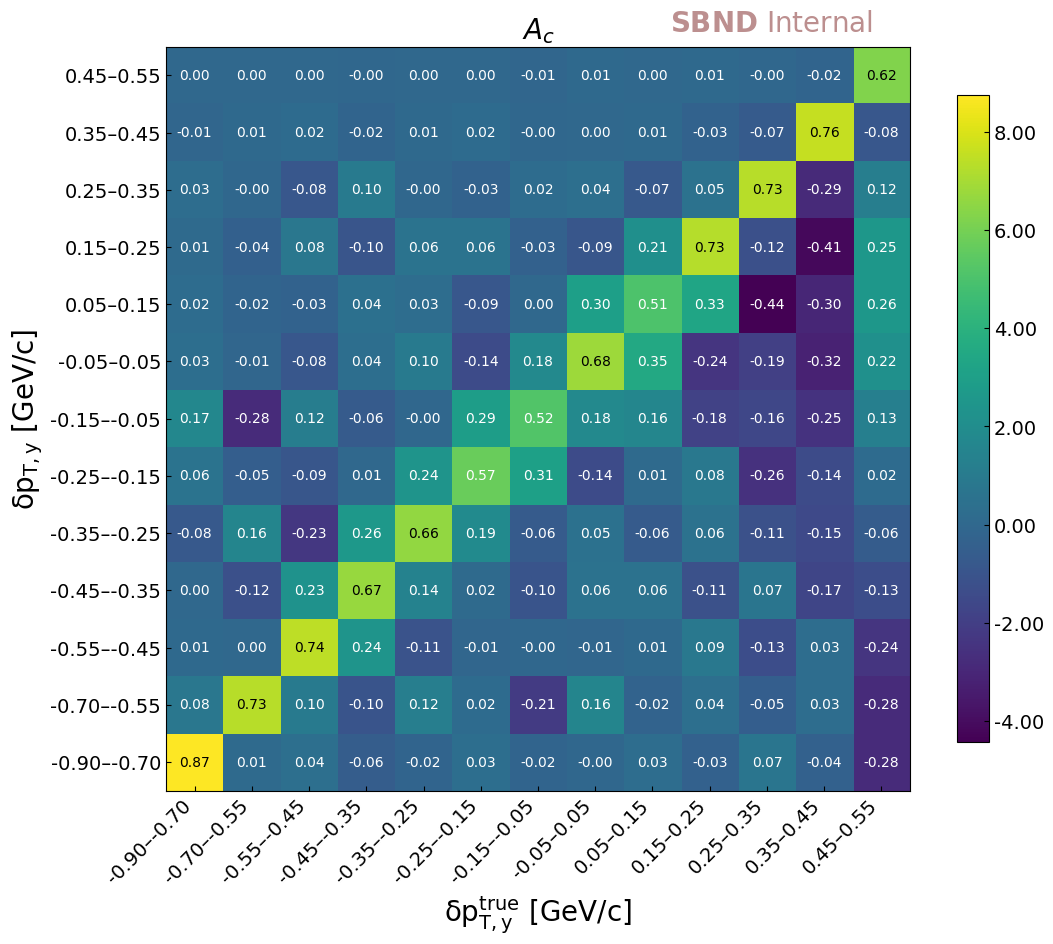


=== tki-del_p ===
tki-del_p         χ²/ndof = 14.9/12
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


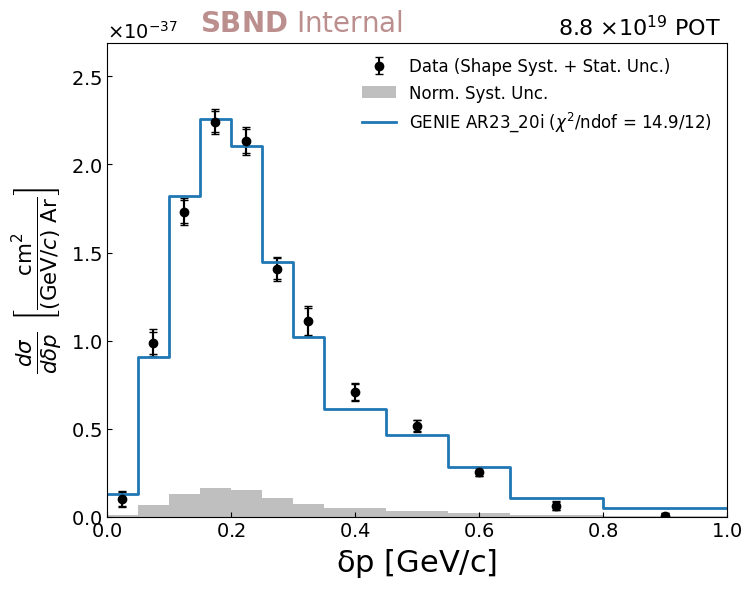

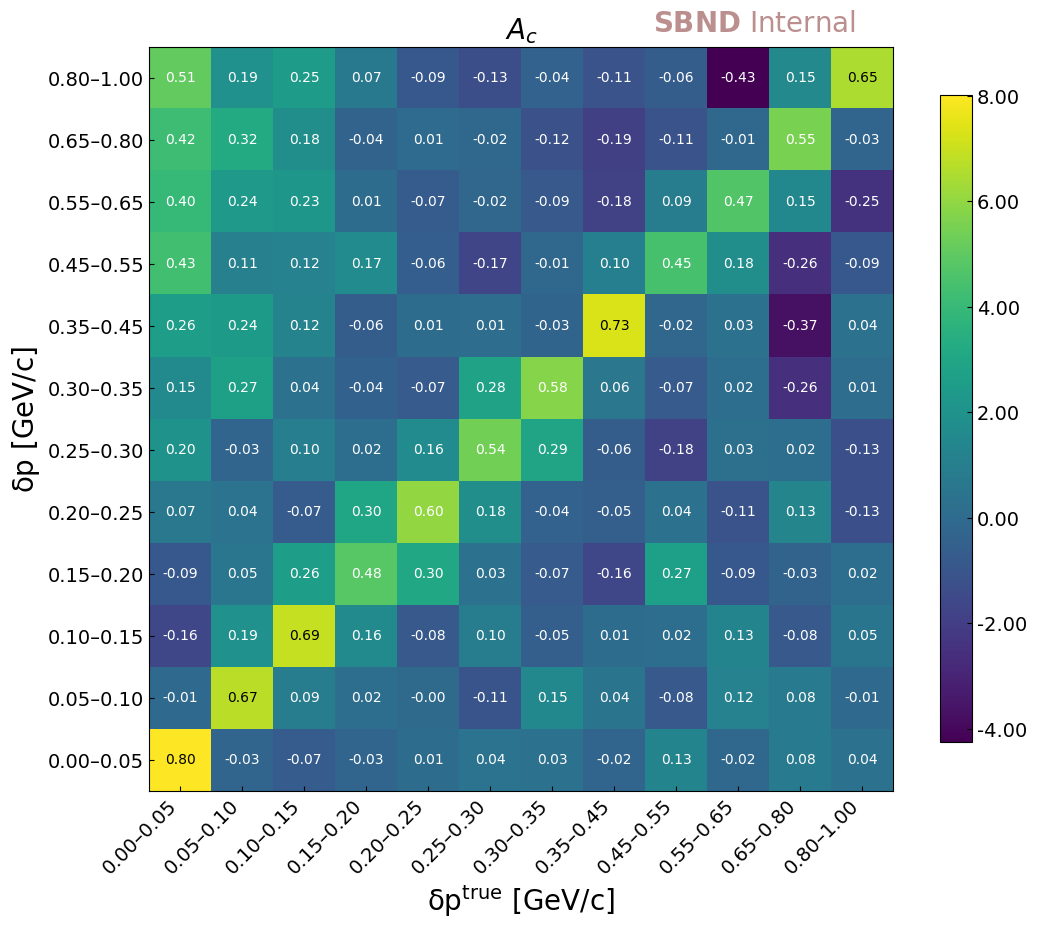


=== tki-del_alpha ===
tki-del_alpha     χ²/ndof = 27.3/8
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


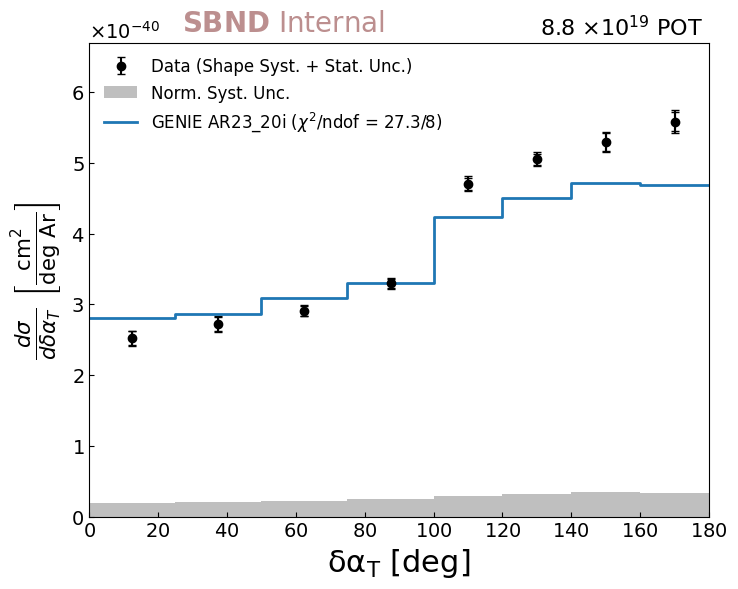

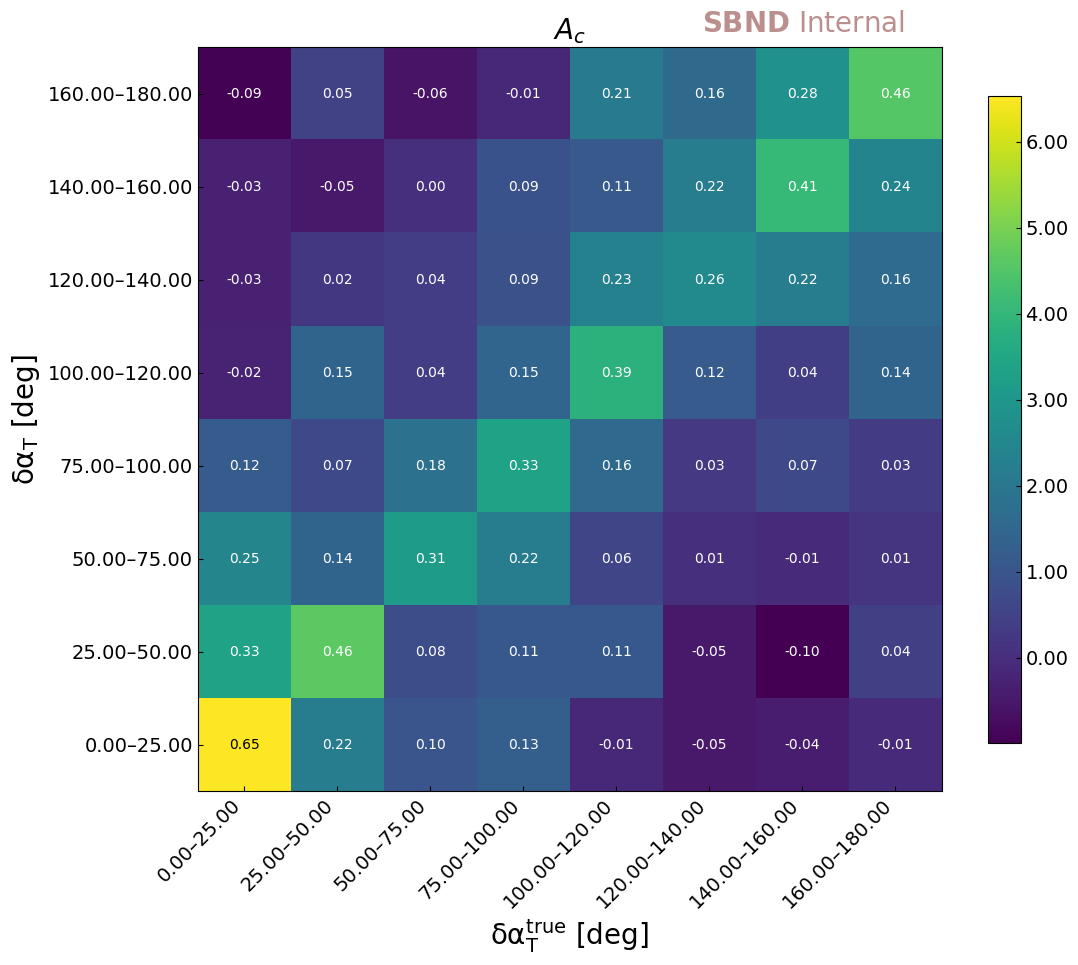


=== tki-del_phi ===
tki-del_phi       χ²/ndof = 10.5/11
  overlay data-bkg sum=16455.1  signal_hists sel_reco sum=16022.0  overlay signal MC sum=15942.4


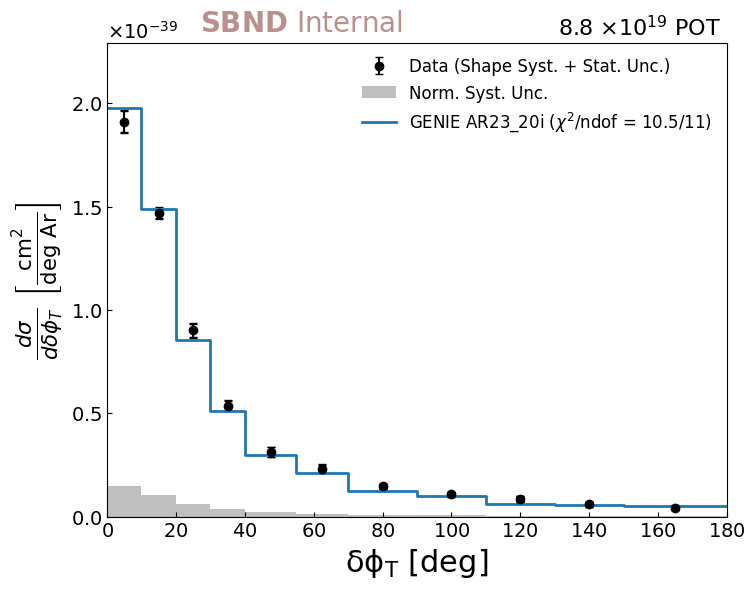

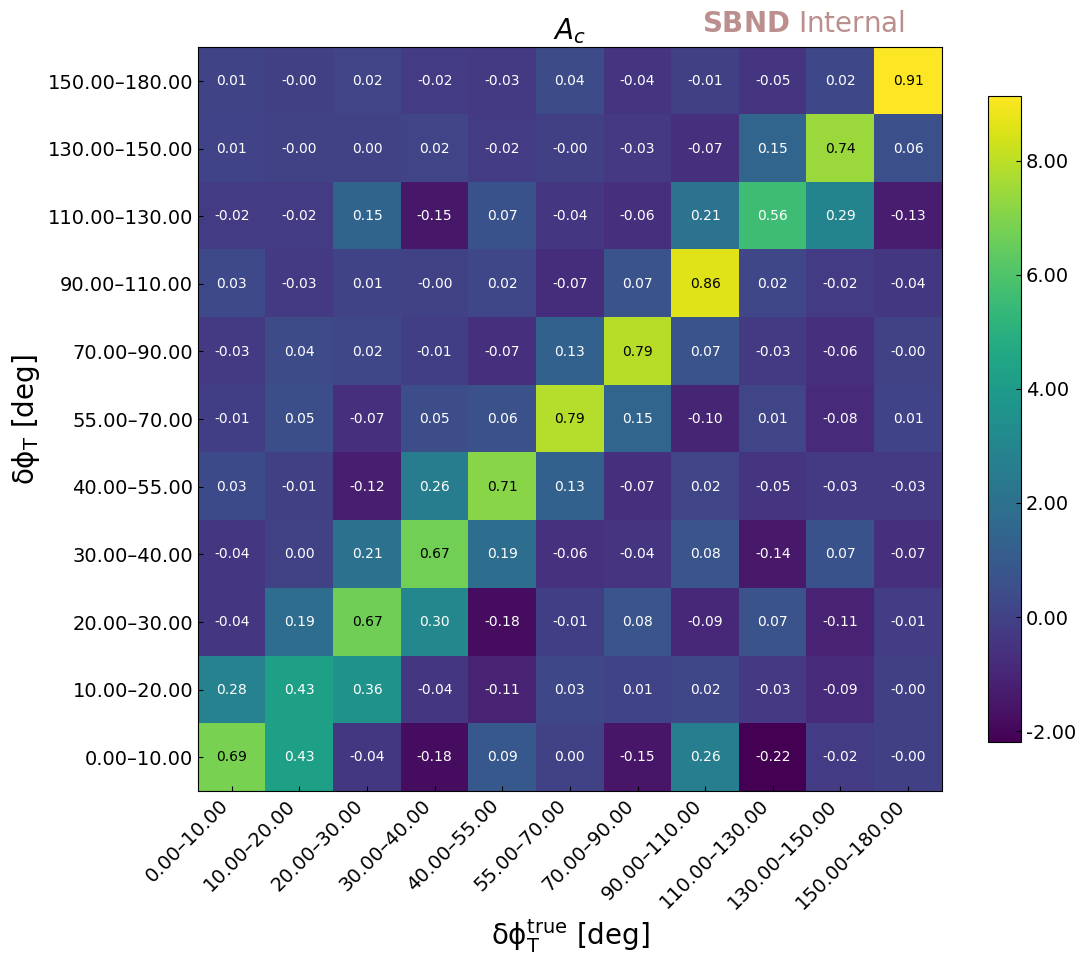

In [15]:
def get_syst_unc(var_config, plot=False):
    return get_category_summary_syst_unc(
        var_config,
        syst_kind=UNFOLDING_SYST_KIND,
        syst_disk_root=SYST_DISK_ROOT,
        category_syst_summary_path=CATEGORY_SUMMARY_NPZ,
    )


def chi2_vs_model(unfold, model, bins):
    bins = np.asarray(bins, dtype=float)
    bw = np.diff(bins) if len(bins) > 2 else np.array([1.0])
    U = np.asarray(unfold["unfold"], dtype=float)
    As = np.asarray(unfold["AddSmear"], dtype=float)
    Uc = np.asarray(unfold["UnfoldCov"], dtype=float)
    cov_pw = Uc * np.outer(1.0 / bw, 1.0 / bw)
    U_pw = U / bw
    M_pw = (As @ np.asarray(model, dtype=float)) / bw
    mask = (U_pw > 0) & (M_pw > 0)
    if not np.any(mask):
        return float("nan"), 0
    diff = U_pw[mask] - M_pw[mask]
    chi2 = float(diff @ np.linalg.solve(cov_pw[np.ix_(mask, mask)], diff))
    return chi2, int(np.sum(mask))


vc_by_name = {vc.var_save_name: vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS}
var_configs = [
    vc_by_name[name]
    for name in var_save_names
    if name in vc_by_name and name != "integrated"
]

results = {
    "meta": {
        "description": (
            "Sanity-check unfold: measured rates from selected_xsec_overlay "
            "overlay_histdata.pkl; response from signal_hists on overlay plot_set MC; "
            "syst from category_syst_summary total_xsec."
        ),
        "overlay_pkl": str(OVERLAY_PKL),
        "overlay_plot_set": dict(plot_set),
        "syst_disk_root": SYST_DISK_ROOT,
        "category_summary_path": str(CATEGORY_SUMMARY_NPZ),
        "unfolding_syst_kind": UNFOLDING_SYST_KIND,
        "data_tot_pot": float(DATA_TOT_POT),
        "xsec_unit": float(xsec_unit),
        "C_type": C_TYPE,
        "Norm_type": NORM_TYPE,
    },
    "variables": {},
}

chi2_summary = {}

for var_config in var_configs:
    vsn = var_config.var_save_name
    key = (vsn, "topology")
    assert key in histdata, f"missing overlay counts for {key}"
    rates = rates_from_overlay(histdata[key])
    bins = np.asarray(var_config.bins, dtype=float)
    assert np.allclose(rates["bins"], bins), (vsn, rates["bins"], bins)

    print(f"\n=== {vsn} ===")
    _, syst_cov_matrix = get_syst_unc(var_config, plot=False)

    ret_signal_hists = signal_hists(
        mc_evt_df,
        mc_nu_df,
        var_config,
        mode="unfold",
        return_data=True,
        plot=False,
        signal_truth_fv="none",
    )
    if len(bins) == 2:
        reco_vs_true = np.array(
            [[float(np.sum(ret_signal_hists["nevts_sel_truth"]))]], dtype=float
        )
    else:
        reco_vs_true, _, _ = np.histogram2d(
            np.asarray(ret_signal_hists["var_sel_truth"], dtype=float),
            np.asarray(ret_signal_hists["var_sel_reco"], dtype=float),
            weights=np.asarray(ret_signal_hists["wgt_sel_truth"], dtype=float),
            bins=bins,
        )
    nevts_allmc = np.asarray(ret_signal_hists["nevts_allmc"], dtype=float)
    nevts_sel_truth = np.asarray(ret_signal_hists["nevts_sel_truth"], dtype=float)
    nevts_sel_reco = np.asarray(ret_signal_hists["nevts_sel_reco"], dtype=float)
    nevts_allsel_reco = np.asarray(ret_signal_hists["nevts_allsel_reco"], dtype=float)
    eff = nevts_sel_truth / nevts_allmc
    response = get_response_matrix(reco_vs_true, eff)

    nevts_data_minus_bkg = np.asarray(rates["data_minus_bkg"], dtype=float)
    measured = nevts_data_minus_bkg * xsec_unit
    model = nevts_allmc * xsec_unit
    Covariance = cov_from_fraccov(syst_cov_matrix, nevts_sel_reco) * xsec_unit**2

    unfold = WienerSVD(
        response, model, measured, Covariance, C_TYPE, NORM_TYPE, stat_scaling=xsec_unit
    )
    chi2, ndof = chi2_vs_model(unfold, model, bins)
    chi2_summary[vsn] = (chi2, ndof)
    print(f"{vsn:16s}  χ²/ndof = {chi2:.1f}/{ndof}")
    print(
        f"  overlay data-bkg sum={float(nevts_data_minus_bkg.sum()):.1f}  "
        f"signal_hists sel_reco sum={float(nevts_sel_reco.sum()):.1f}  "
        f"overlay signal MC sum={float(rates['signal_mc'].sum()):.1f}"
    )

    results["variables"][vsn] = {
        "bins": bins,
        "bin_centers": np.asarray(var_config.bin_centers, dtype=float),
        "ingredients": {
            "nevts_data_minus_bkg": nevts_data_minus_bkg,
            "nevts_mc_bkgd": np.asarray(rates["bkg_mc"], dtype=float),
            "nevts_data": np.asarray(rates["data"], dtype=float),
            "nevts_signal_mc_overlay": np.asarray(rates["signal_mc"], dtype=float),
            "nevts_allmc": nevts_allmc,
            "nevts_sel_reco": nevts_sel_reco,
            "nevts_sel_truth": nevts_sel_truth,
            "nevts_allsel_reco": nevts_allsel_reco,
            "reco_vs_true": np.asarray(reco_vs_true, dtype=float),
            "efficiency": np.asarray(eff, dtype=float),
            "response": np.asarray(response, dtype=float),
            "frac_cov": np.asarray(syst_cov_matrix, dtype=float),
            "Covariance_xsec": np.asarray(Covariance, dtype=float),
        },
        "results": {
            "measured": measured,
            "model": model,
            "unfold": np.asarray(unfold["unfold"], dtype=float),
            "AddSmear": np.asarray(unfold["AddSmear"], dtype=float),
            "UnfoldCov": np.asarray(unfold["UnfoldCov"], dtype=float),
            "StatUnfoldCov": np.asarray(unfold["StatUnfoldCov"], dtype=float),
            "SystUnfoldCov": np.asarray(unfold["SystUnfoldCov"], dtype=float),
            "stat_err": np.sqrt(np.maximum(np.diag(unfold["StatUnfoldCov"]), 0.0)),
            "syst_err": np.sqrt(np.maximum(np.diag(unfold["SystUnfoldCov"]), 0.0)),
            "total_err": np.sqrt(np.maximum(np.diag(unfold["UnfoldCov"]), 0.0)),
            "chi2_genie": float(chi2),
            "ndof": int(ndof),
        },
        "var_save_name": vsn,
    }

    if save_fig:
        save_name = str(SAVE_FIG_DIR / f"{vsn}-unfolded_event_rates-data")
        models = {"GENIE AR23_20i": [model, "C0"]}
        plot_unfolded_result(
            unfold,
            measured,
            models,
            var_config,
            xsec_unit=xsec_unit,
            save_fig=True,
            save_name=save_name,
            textloc=[0.05, 0.4],
            approval=approval,
            data=True,
            closure_test=False,
        )
        plot_heatmap(
            unfold["AddSmear"],
            bins,
            plot_labels=[var_config.var_labels[2], var_config.var_labels[0], "", "$A_c$"],
            approval=approval,
            save_fig=True,
            save_name=str(SAVE_FIG_DIR / f"{vsn}-data-add_smear"),
            cmap="viridis",
        )


## Optional: `integrated` (sum of a multi-bin variable)


In [16]:
if "tki-del_Tp" in results["variables"]:
    ref = results["variables"]["tki-del_Tp"]
    ing = ref["ingredients"]
    vc_int = VariableConfig.all_events()
    bins_int = np.asarray(vc_int.bins, dtype=float)

    def _sum(a):
        return np.asarray([float(np.sum(a))], dtype=float)

    nevts_allmc_i = _sum(ing["nevts_allmc"])
    nevts_sel_reco_i = _sum(ing["nevts_sel_reco"])
    nevts_sel_truth_i = _sum(ing["nevts_sel_truth"])
    nevts_allsel_reco_i = _sum(ing["nevts_allsel_reco"])
    nevts_data_minus_bkg_i = _sum(ing["nevts_data_minus_bkg"])
    nevts_mc_bkgd_i = _sum(ing["nevts_mc_bkgd"])

    eff_i = nevts_sel_truth_i / nevts_allmc_i
    reco_vs_true_i = np.array([[float(nevts_sel_truth_i[0])]], dtype=float)
    response_i = get_response_matrix(reco_vs_true_i, eff_i)

    measured_i = nevts_data_minus_bkg_i * xsec_unit
    model_i = nevts_allmc_i * xsec_unit

    _, frac_cov_i = get_syst_unc(vc_int, plot=False)
    Cov_i = cov_from_fraccov(frac_cov_i, nevts_sel_reco_i) * xsec_unit**2

    unfold_i = WienerSVD(
        response_i, model_i, measured_i, Cov_i, C_TYPE, NORM_TYPE, stat_scaling=xsec_unit
    )
    chi2_i, ndof_i = chi2_vs_model(unfold_i, model_i, bins_int)
    chi2_summary["integrated"] = (chi2_i, ndof_i)
    print(f"integrated       χ²/ndof = {chi2_i:.1f}/{ndof_i}")

    results["variables"]["integrated"] = {
        "bins": bins_int,
        "bin_centers": np.asarray(vc_int.bin_centers, dtype=float),
        "ingredients": {
            "nevts_data_minus_bkg": nevts_data_minus_bkg_i,
            "nevts_mc_bkgd": nevts_mc_bkgd_i,
            "nevts_allmc": nevts_allmc_i,
            "nevts_sel_reco": nevts_sel_reco_i,
            "nevts_sel_truth": nevts_sel_truth_i,
            "nevts_allsel_reco": nevts_allsel_reco_i,
            "reco_vs_true": reco_vs_true_i,
            "efficiency": eff_i,
            "response": np.asarray(response_i, dtype=float),
            "frac_cov": np.asarray(frac_cov_i, dtype=float),
            "Covariance_xsec": Cov_i,
        },
        "results": {
            "measured": measured_i,
            "model": model_i,
            "unfold": np.asarray(unfold_i["unfold"], dtype=float),
            "AddSmear": np.asarray(unfold_i["AddSmear"], dtype=float),
            "UnfoldCov": np.asarray(unfold_i["UnfoldCov"], dtype=float),
            "StatUnfoldCov": np.asarray(unfold_i["StatUnfoldCov"], dtype=float),
            "SystUnfoldCov": np.asarray(unfold_i["SystUnfoldCov"], dtype=float),
            "stat_err": np.sqrt(np.maximum(np.diag(unfold_i["StatUnfoldCov"]), 0.0)),
            "syst_err": np.sqrt(np.maximum(np.diag(unfold_i["SystUnfoldCov"]), 0.0)),
            "total_err": np.sqrt(np.maximum(np.diag(unfold_i["UnfoldCov"]), 0.0)),
            "chi2_genie": float(chi2_i),
            "ndof": int(ndof_i),
        },
        "var_save_name": "integrated",
    }
else:
    print("skip integrated: tki-del_Tp not in results")


integrated       χ²/ndof = 0.1/1


In [17]:
with open(OUT_PKL, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

print("wrote", OUT_PKL)
print("\nχ² summary:")
for vsn, (chi2, ndof) in sorted(chi2_summary.items()):
    print(f"  {vsn:16s}  {chi2:.1f}/{ndof}")


wrote /exp/sbnd/data/users/munjung/sanity_check/selected_chi2fix_qual_cut/unfold_sanity/unfolding_ingredients_and_results.pkl

χ² summary:
  integrated        0.1/1
  muon-dir_z        98.2/14
  muon-p            11.0/12
  proton-dir_z      21.9/10
  proton-p          47.1/13
  tki-del_Tp        36.8/12
  tki-del_Tp_x      16.0/13
  tki-del_Tp_y      46.6/13
  tki-del_alpha     27.3/8
  tki-del_p         14.9/12
  tki-del_phi       10.5/11
